In [1]:
import pandas as pd
import numpy as np
import requests
from bs4 import BeautifulSoup
import geopandas as gpd
import folium
import matplotlib.pyplot as plt
import seaborn as sns

print("All imports successful")

/Users/makafuiayegbe/Code/Data Analyst Projects/toronto-affordability-index/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


All imports successful


In [2]:
import urllib.request
import zipfile
import os

# Download Toronto neighbourhood shapefiles
url = "https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/4def3f65-2a65-4a4f-83A4-be5254b0f309/resource/a083c865-6d60-4d1d-b6c6-b0c8a85f9c15/download/Neighbourhoods%20-%204326.zip"

os.makedirs("../data", exist_ok=True)

urllib.request.urlretrieve(url, "../data/toronto_neighbourhoods.zip")

with zipfile.ZipFile("../data/toronto_neighbourhoods.zip", "r") as z:
    z.extractall("../data/toronto_neighbourhoods")

print("Download complete")
print(os.listdir("../data/toronto_neighbourhoods"))

HTTPError: HTTP Error 404: Not Found

In [3]:
import urllib.request
import zipfile
import os

# Download Toronto neighbourhood shapefiles
url = "https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/4def3f65-2a65-4a4f-83A4-be5254b0f309/resource/a083c865-6d60-4d1d-b6c6-b0c8a85f9c15/download/Neighbourhoods%20-%204326.zip"

os.makedirs("../data", exist_ok=True)

urllib.request.urlretrieve(url, "../data/toronto_neighbourhoods.zip")

with zipfile.ZipFile("../data/toronto_neighbourhoods.zip", "r") as z:
    z.extractall("../data/toronto_neighbourhoods")

print("Download complete")
print(os.listdir("../data/toronto_neighbourhoods"))

HTTPError: HTTP Error 404: Not Found

In [4]:
# Load Toronto neighbourhood boundaries
neighbourhoods = gpd.read_file("../data/Neighbourhoods_4326.geojson")

print(neighbourhoods.shape)
print(neighbourhoods.columns.tolist())
neighbourhoods.head()

(158, 12)
['_id', 'AREA_ID', 'AREA_ATTR_ID', 'PARENT_AREA_ID', 'AREA_SHORT_CODE', 'AREA_LONG_CODE', 'AREA_NAME', 'AREA_DESC', 'CLASSIFICATION', 'CLASSIFICATION_CODE', 'OBJECTID', 'geometry']


,_id,AREA_ID,AREA_ATTR_ID,PARENT_AREA_ID,AREA_SHORT_CODE,AREA_LONG_CODE,AREA_NAME,AREA_DESC,CLASSIFICATION,CLASSIFICATION_CODE,OBJECTID,geometry
0,1,2502366,26022881,None,174,174,South Eglinton-Davisville,South Eglinton-Davisville (174),Not an NIA or Emerging Neighbourhood,NA,17824737.0,"MULTIPOLYGON (((-79.38635 43.69783, -79.38623 ..."
1,2,2502365,26022880,None,173,173,North Toronto,North Toronto (173),Not an NIA or Emerging Neighbourhood,NA,17824753.0,"MULTIPOLYGON (((-79.39744 43.70693, -79.39837 ..."
2,3,2502364,26022879,None,172,172,Dovercourt Village,Dovercourt Village (172),Not an NIA or Emerging Neighbourhood,NA,17824769.0,"MULTIPOLYGON (((-79.43411 43.66015, -79.43537 ..."
3,4,2502363,26022878,None,171,171,Junction-Wallace Emerson,Junction-Wallace Emerson (171),Not an NIA or Emerging Neighbourhood,NA,17824785.0,"MULTIPOLYGON (((-79.4387 43.66766, -79.43841 4..."
4,5,2502362,26022877,None,170,170,Yonge-Bay Corridor,Yonge-Bay Corridor (170),Not an NIA or Emerging Neighbourhood,NA,17824801.0,"MULTIPOLYGON (((-79.38404 43.64497, -79.38502 ..."


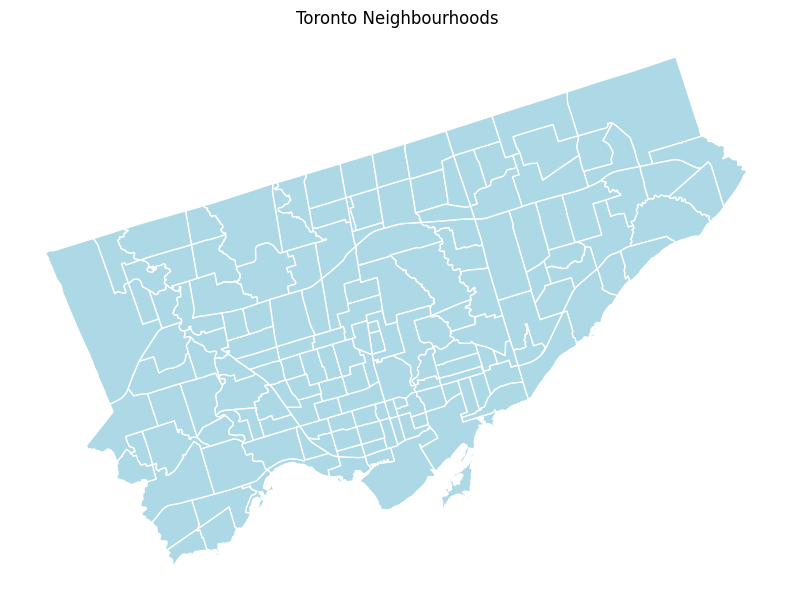

In [5]:
# filter what i need
neighbourhoods = neighbourhoods[['AREA_NAME', 'geometry']]

# visual check... plot neighbourhoods
neighbourhoods.plot(figsize=(10, 10), color='lightblue', edgecolor='white')
plt.title("Toronto Neighbourhoods")
plt.axis('off')
plt.show()

In [6]:
# load data
rentals = pd.read_csv("../data/rentfaster.csv")

print(rentals.shape)
print(rentals.columns.tolist())
rentals.head()

(25771, 18)
['rentfaster_id', 'city', 'province', 'address', 'latitude', 'longitude', 'lease_term', 'type', 'price', 'beds', 'baths', 'sq_feet', 'link', 'furnishing', 'availability_date', 'smoking', 'cats', 'dogs']


,rentfaster_id,city,province,address,latitude,longitude,lease_term,type,price,beds,baths,sq_feet,link,furnishing,availability_date,smoking,cats,dogs
0,468622,Airdrie,Alberta,69 Gateway Dr NE,51.305962,-114.012515,Long Term,Townhouse,2495.0,2 Beds,2.5,1403,/ab/airdrie/rentals/townhouse/2-bedrooms/pet-f...,Unfurnished,Immediate,Non-Smoking,True,True
1,468622,Airdrie,Alberta,69 Gateway Dr NE,51.305962,-114.012515,Long Term,Townhouse,2695.0,3 Beds,2.5,1496,/ab/airdrie/rentals/townhouse/2-bedrooms/pet-f...,Unfurnished,Immediate,Non-Smoking,True,True
2,468622,Airdrie,Alberta,69 Gateway Dr NE,51.305962,-114.012515,Long Term,Townhouse,2295.0,2 Beds,2.5,1180,/ab/airdrie/rentals/townhouse/2-bedrooms/pet-f...,Unfurnished,Immediate,Non-Smoking,True,True
3,468622,Airdrie,Alberta,69 Gateway Dr NE,51.305962,-114.012515,Long Term,Townhouse,2095.0,2 Beds,2.5,1403,/ab/airdrie/rentals/townhouse/2-bedrooms/pet-f...,Unfurnished,November 18,Non-Smoking,True,True
4,468622,Airdrie,Alberta,69 Gateway Dr NE,51.305962,-114.012515,Long Term,Townhouse,2495.0,2 Beds,2.5,1403,/ab/airdrie/rentals/townhouse/2-bedrooms/pet-f...,Unfurnished,Immediate,Non-Smoking,True,True


In [7]:
# filter for Toronto only
toronto_rentals = rentals[rentals['city'].str.lower() == 'toronto']

print(f"Total listings: {len(toronto_rentals)}")
print(f"Price range: ${toronto_rentals['price'].min()} - ${toronto_rentals['price'].max()}")
print(f"Nulls:\n{toronto_rentals[['price', 'beds', 'latitude', 'longitude']].isnull().sum()}")
toronto_rentals.head()

Total listings: 2893
Price range: $0.0 - $19170.0
Nulls:
price        0
beds         0
latitude     0
longitude    0
dtype: int64


,rentfaster_id,city,province,address,latitude,longitude,lease_term,type,price,beds,baths,sq_feet,link,furnishing,availability_date,smoking,cats,dogs
19563,365942,Toronto,Ontario,39 Niagara Street,43.641615,-79.400881,Long Term,Apartment,2227.0,Studio,1,NaN,/on/toronto/rentals/apartment/1-bedroom/pet-fr...,Unfurnished,Immediate,Non-Smoking,True,True
19564,365942,Toronto,Ontario,39 Niagara Street,43.641615,-79.400881,Long Term,Apartment,2299.0,1 Bed,1,NaN,/on/toronto/rentals/apartment/1-bedroom/pet-fr...,Unfurnished,Immediate,Non-Smoking,True,True
19565,365942,Toronto,Ontario,39 Niagara Street,43.641615,-79.400881,Long Term,Apartment,2668.0,1 Bed,2,NaN,/on/toronto/rentals/apartment/1-bedroom/pet-fr...,Unfurnished,Immediate,Non-Smoking,True,True
19566,365942,Toronto,Ontario,39 Niagara Street,43.641615,-79.400881,Long Term,Apartment,3812.0,2 Beds,2,NaN,/on/toronto/rentals/apartment/1-bedroom/pet-fr...,Unfurnished,Immediate,Non-Smoking,True,True
19567,365942,Toronto,Ontario,39 Niagara Street,43.641615,-79.400881,Long Term,Apartment,4124.0,3 Beds,2,NaN,/on/toronto/rentals/apartment/1-bedroom/pet-fr...,Unfurnished,Immediate,Non-Smoking,True,True


In [ ]:
# get Toronot copy
toronto_rentals = rentals[rentals['city'] == 'Toronto'].copy()

# converting beds text to numbers
beds_mapping = {
    'Studio': 0.5,
    'Bachelor': 0.5,
    '1 Bed': 1,
    '2 Beds': 2,
    '3 Beds': 3,
    '4 Beds': 4,
    '5 Beds': 5,
    '6 Beds': 6,
}
toronto_rentals['beds'] = toronto_rentals['beds'].map(beds_mapping)

# Convert price
toronto_rentals['price'] = pd.to_numeric(toronto_rentals['price'], errors='coerce')

# Drop nulls
toronto_rentals = toronto_rentals.dropna(subset=['price', 'beds', 'latitude', 'longitude'])

# Filter outliers
toronto_rentals = toronto_rentals[
    (toronto_rentals['price'] >= 500) &
    (toronto_rentals['price'] <= 10000)
]

print(f"Cleaned listings: {len(toronto_rentals)}")
print(f"Price range: ${toronto_rentals['price'].min()} - ${toronto_rentals['price'].max()}")
print(f"Avg price: ${toronto_rentals['price'].mean():.2f}")
print(f"Bed types: {sorted(toronto_rentals['beds'].unique())}")